In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import cv2
import skimage
from pathlib import Path

In [4]:
# iterate over C:\Users\UdaRe\OneDrive\Documenti\GitHub\iapr2026do\project\L1000765\crops_L1000765 but also over L1000766, L1000767, L1000768 and save the augmented images in a new folder called augmented_crops_L1000765, augmented_crops_L1000766, augmented_crops_L1000767, augmented_crops_L1000768 respectively
ref = Path.cwd().resolve()
crops = "L1000765\\crops_L1000765"
augmented_crops = "L1000765\\augmented_crops_L1000765"


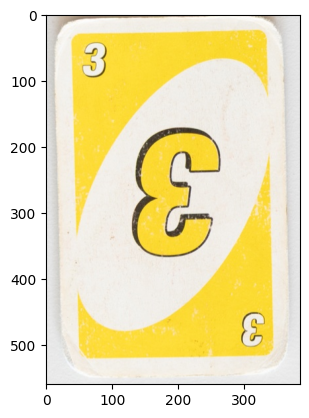

In [5]:
# open crop_0 in crops_L1000765 and display it
img = Image.open(os.path.join(ref, crops, "crop_0.jpg"))
plt.imshow(img)

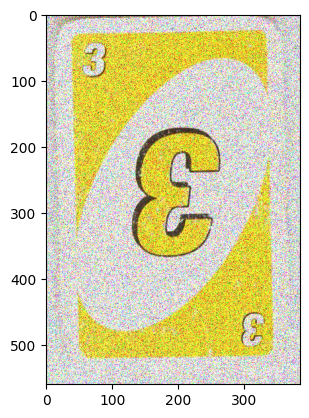

In [6]:
# add speckle noise to the image and display it
img_array = np.array(img)
noisy_img = skimage.util.random_noise(img_array, mode='speckle', var=0.1)
plt.imshow(noisy_img)

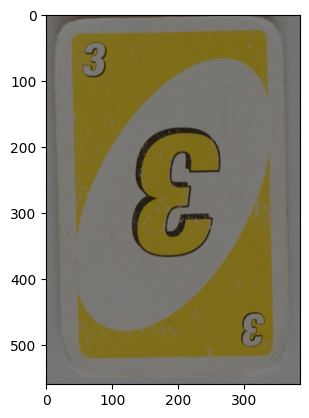

In [7]:
# dim the image and display it
dimmed_img = cv2.convertScaleAbs(img_array, alpha=0.5, beta=0)
plt.imshow(dimmed_img)

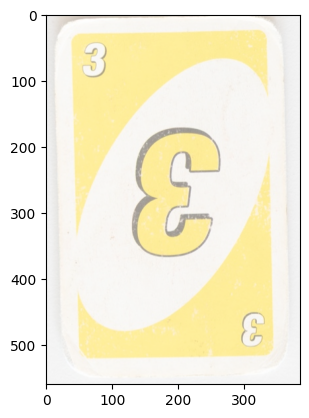

In [8]:
# lower contrast the image and display it
lower_contrast_img = cv2.convertScaleAbs(img_array, alpha=0.5, beta=128)
plt.imshow(lower_contrast_img)

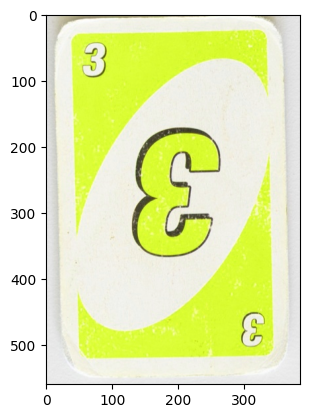

In [9]:
# change hue 
hue_img1 = cv2.cvtColor(img_array, cv2.COLOR_RGB2HSV)
hue_img1[:, :, 0] = (hue_img1[:, :, 0] + 10) % 180
hue_img1 = cv2.cvtColor(hue_img1, cv2.COLOR_HSV2RGB)
plt.imshow(hue_img1)

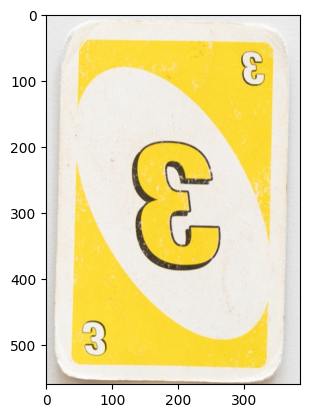

In [10]:
# flip vertically and display it
flipped_img = cv2.flip(img_array, 0)
plt.imshow(flipped_img)

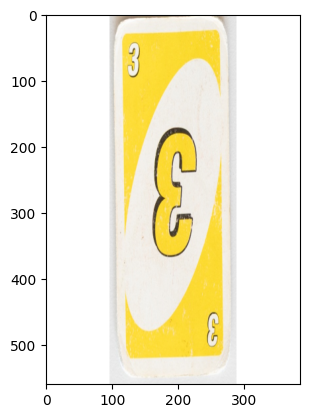

In [11]:
# squeeze (change proportion) the image and display it (can also stretch)
squeezed_img = cv2.resize(img_array, (img_array.shape[1] // 2, img_array.shape[0]))
# now we create a white image of the original size and paste the squeezed image in the center
squeezed_img_full = np.ones_like(img_array) * 255
# calculate the position to paste the squeezed image
x_offset = (squeezed_img_full.shape[1] - squeezed_img.shape[1]) // 2
y_offset = (squeezed_img_full.shape[0] - squeezed_img.shape[0]) // 2
squeezed_img_full[y_offset:y_offset + squeezed_img.shape[0], x_offset:x_offset + squeezed_img.shape[1]] = squeezed_img
plt.imshow(squeezed_img_full)

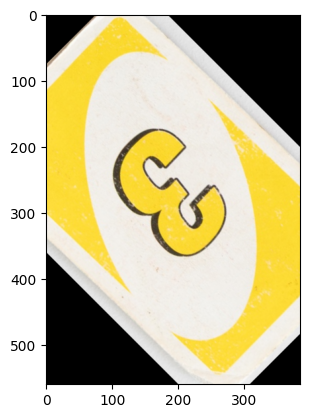

In [12]:
# rotate the image by 45 degrees and display it
(h, w) = img_array.shape[:2]
center = (w // 2, h // 2)
M = cv2.getRotationMatrix2D(center, 45, 1.0)
rotated_img = cv2.warpAffine(img_array, M, (w, h))
plt.imshow(rotated_img)

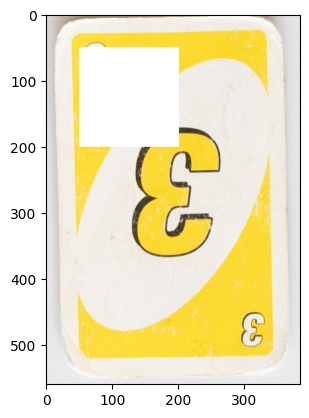

In [13]:
# cover the image with a white rectangle and display it
covered_img = img_array.copy()
cv2.rectangle(covered_img, (50, 50), (200, 200), (255, 255, 255), -1)
plt.imshow(covered_img)

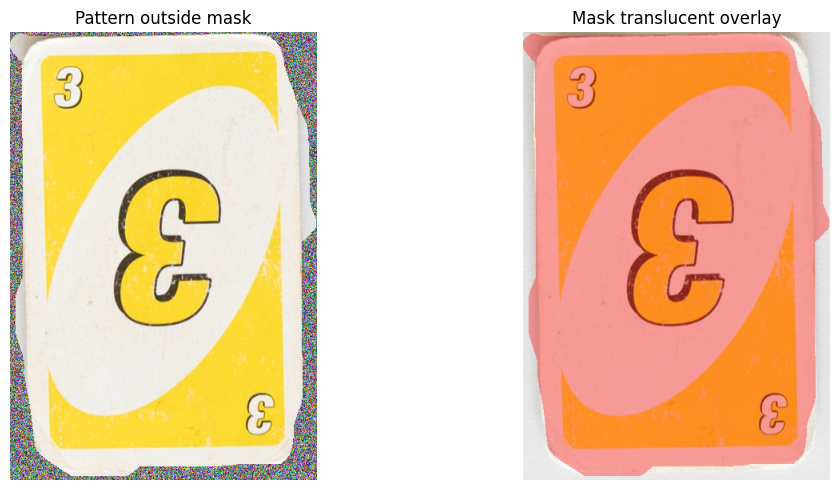

In [14]:
# replace pixels that aren't in mask (C:\Users\UdaRe\OneDrive\Documenti\GitHub\iapr2026do\project\L1000765\components_L1000766) with random colored patterns and display it
mask_path = os.path.join(ref, "L1000765\\closed_components_L1000765\\closed_component_0.jpg")
closed_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

# Use the same crop logic as reference_cards.ipynb
x, y, w, h = cv2.boundingRect(closed_mask)
mask_crop = closed_mask[y:y+h, x:x+w]

# Keep compatibility if jpeg rounding introduces a 1-2 px mismatch
if mask_crop.shape[:2] != img_array.shape[:2]:
    mask_crop = cv2.resize(mask_crop, (img_array.shape[1], img_array.shape[0]), interpolation=cv2.INTER_NEAREST)

mask_fg = mask_crop > 127
pattern_img = np.random.randint(0, 255, img_array.shape, dtype=np.uint8)
pattern_img[mask_fg] = img_array[mask_fg]

# translucent mask overlay on top of the original crop
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].imshow(pattern_img)
ax[0].set_title("Pattern outside mask")
ax[0].axis("off")

ax[1].imshow(img_array)
overlay = np.zeros((*mask_fg.shape, 4), dtype=np.float32)
overlay[..., 0] = 1.0  # red channel
overlay[..., 3] = mask_fg.astype(np.float32) * 0.35  # alpha where mask is foreground
ax[1].imshow(overlay)
ax[1].set_title("Mask translucent overlay")
ax[1].axis("off")

plt.tight_layout()

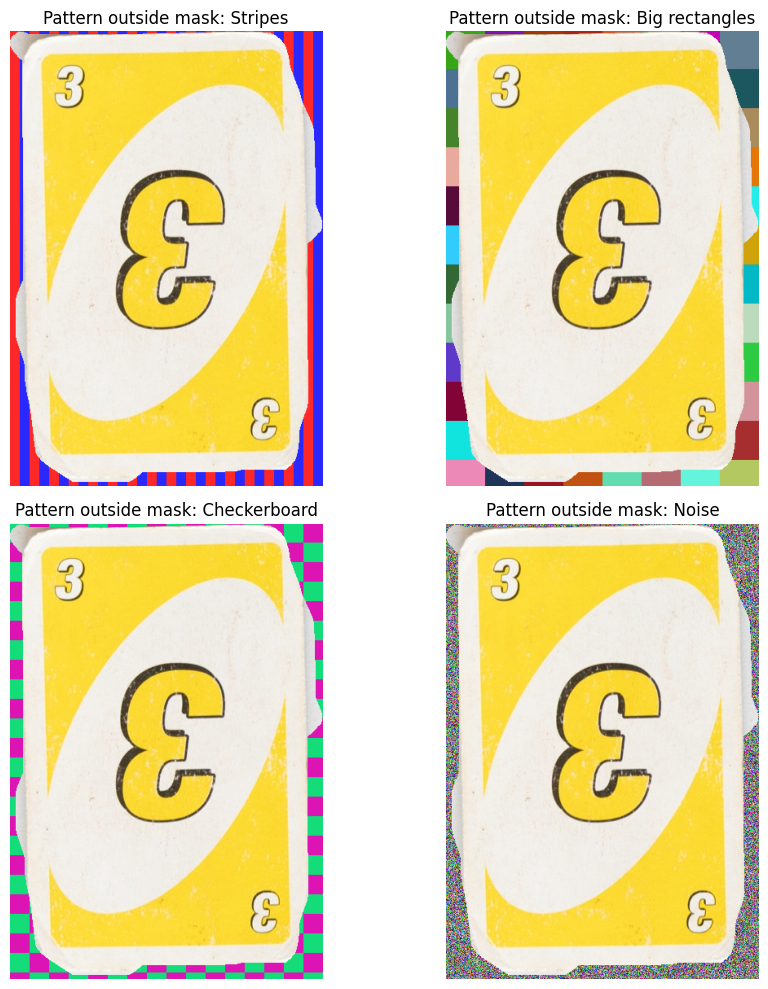

In [15]:
# same thing as above but different patterns: striped, bigger colored rectangles, checkerboard, etc.
# Recompute the aligned mask so this cell can run independently
mask_path = os.path.join(ref, "L1000765\\closed_components_L1000765\\closed_component_0.jpg")
closed_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
x, y, w, h = cv2.boundingRect(closed_mask)
mask_crop = closed_mask[y:y+h, x:x+w]
if mask_crop.shape[:2] != img_array.shape[:2]:
    mask_crop = cv2.resize(mask_crop, (img_array.shape[1], img_array.shape[0]), interpolation=cv2.INTER_NEAREST)
mask_fg = mask_crop > 127

H, W = img_array.shape[:2]

# 1) Vertical stripes
stripe_w = 12
stripe_pattern = np.zeros_like(img_array)
for c in range(0, W, stripe_w * 2):
    stripe_pattern[:, c:c+stripe_w] = (255, 40, 40)
    stripe_pattern[:, c+stripe_w:c+2*stripe_w] = (40, 40, 255)

# 2) Big colored rectangles (blocky mosaic)
block = 48
rect_pattern = np.zeros_like(img_array)
for r in range(0, H, block):
    for c in range(0, W, block):
        color = np.random.randint(0, 256, size=3, dtype=np.uint8)
        rect_pattern[r:r+block, c:c+block] = color

# 3) Checkerboard
tile = 24
checker_pattern = np.zeros_like(img_array)
for r in range(0, H, tile):
    for c in range(0, W, tile):
        if ((r // tile) + (c // tile)) % 2 == 0:
            checker_pattern[r:r+tile, c:c+tile] = (20, 220, 120)
        else:
            checker_pattern[r:r+tile, c:c+tile] = (220, 20, 180)

# 4) Random noise
noise_pattern = np.random.randint(0, 255, img_array.shape, dtype=np.uint8)

patterns = [
    ("Stripes", stripe_pattern),
    ("Big rectangles", rect_pattern),
    ("Checkerboard", checker_pattern),
    ("Noise", noise_pattern),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.ravel()

for i, (name, pattern) in enumerate(patterns):
    out = pattern.copy()
    out[mask_fg] = img_array[mask_fg]
    axes[i].imshow(out)
    axes[i].set_title(f"Pattern outside mask: {name}")
    axes[i].axis("off")

plt.tight_layout()

In [16]:
# batch augment all crops, save images to aug/, and write aug.csv
import csv

source_tags = ["L1000765", "L1000766", "L1000767", "L1000768"]
aug_dir = os.path.join(ref, "aug")
reference_csv_path = os.path.join(ref, "reference.csv")
aug_csv_path = os.path.join(ref, "aug.csv")
os.makedirs(aug_dir, exist_ok=True)

# Load labels from reference.csv: image_id -> card
ref_labels = {}
with open(reference_csv_path, "r", newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        img_id = row["image_id"].strip()
        card = row["card"].strip()
        if img_id:
            ref_labels[img_id] = card

def load_aligned_mask(closed_dir, crop_idx, target_h, target_w):
    mask_path = os.path.join(closed_dir, f"closed_component_{crop_idx}.jpg")
    closed_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if closed_mask is None:
        raise FileNotFoundError(f"Mask not found: {mask_path}")

    x, y, w, h = cv2.boundingRect(closed_mask)
    mask_crop = closed_mask[y:y+h, x:x+w]

    if mask_crop.shape[:2] != (target_h, target_w):
        mask_crop = cv2.resize(mask_crop, (target_w, target_h), interpolation=cv2.INTER_NEAREST)

    return mask_crop > 127

def make_pattern_variants(h, w):
    patterns = {}

    # 1) vertical stripes
    stripe_w = 12
    stripe = np.zeros((h, w, 3), dtype=np.uint8)
    for c in range(0, w, stripe_w * 2):
        stripe[:, c:c+stripe_w] = (0, 0, 255)
        stripe[:, c+stripe_w:c+2*stripe_w] = (255, 0, 0)
    patterns["pattern_stripes"] = stripe

    # 2) big rectangles
    block = 48
    rects = np.zeros((h, w, 3), dtype=np.uint8)
    for r in range(0, h, block):
        for c in range(0, w, block):
            rects[r:r+block, c:c+block] = np.random.randint(0, 256, size=3, dtype=np.uint8)
    patterns["pattern_big_rectangles"] = rects

    # 3) checkerboard
    tile = 24
    checker = np.zeros((h, w, 3), dtype=np.uint8)
    for r in range(0, h, tile):
        for c in range(0, w, tile):
            if ((r // tile) + (c // tile)) % 2 == 0:
                checker[r:r+tile, c:c+tile] = (20, 220, 120)
            else:
                checker[r:r+tile, c:c+tile] = (220, 20, 180)
    patterns["pattern_checkerboard"] = checker

    # 4) random noise pattern
    patterns["pattern_noise"] = np.random.randint(0, 256, size=(h, w, 3), dtype=np.uint8)

    return patterns

def apply_pattern_background(img_bgr, mask_fg, pattern_bgr):
    out = pattern_bgr.copy()
    out[mask_fg] = img_bgr[mask_fg]
    return out

aug_rows = []

for source_tag in source_tags:
    crops_dir = os.path.join(ref, source_tag, f"crops_{source_tag}")
    closed_dir = os.path.join(ref, source_tag, f"closed_components_{source_tag}")

    if not os.path.isdir(crops_dir):
        print(f"Skipping {source_tag}: crops folder not found ({crops_dir})")
        continue

    crop_files = sorted([f for f in os.listdir(crops_dir) if f.lower().endswith(".jpg") and f.startswith("crop_")])

    for crop_file in crop_files:
        crop_idx = int(crop_file.split("_")[1].split(".")[0])
        base_id = f"{source_tag}_crop_{crop_idx}"
        card_label = ref_labels.get(base_id)
        if card_label is None:
            print(f"Skipping {base_id}: no label found in reference.csv")
            continue

        img_path = os.path.join(crops_dir, crop_file)
        img_bgr = cv2.imread(img_path, cv2.IMREAD_COLOR)
        if img_bgr is None:
            print(f"Skipping unreadable image: {img_path}")
            continue

        h, w = img_bgr.shape[:2]

        # If mask is missing, continue with all augmentations except pattern backgrounds
        mask_fg = None
        try:
            mask_fg = load_aligned_mask(closed_dir, crop_idx, h, w)
        except FileNotFoundError as e:
            print(f"{e} -> skipping background pattern augmentations for {base_id}")

        aug_images = []

        # 1) rotation (fixed 45 degrees)
        (h, w) = img_bgr.shape[:2]
        center = (w // 2, h // 2)
        M = cv2.getRotationMatrix2D(center, 45, 1.0)
        rotated_img = cv2.warpAffine(img_bgr, M, (w, h))
        aug_images.append(("rot_45", rotated_img))

        # 2) flips
        aug_images.append(("flip_vertical", cv2.flip(img_bgr, 0)))
        aug_images.append(("flip_horizontal", cv2.flip(img_bgr, 1)))

        # 3) hue change (3 small random hue shifts)
        # Keep shifts small so yellow stays in the yellow family.
        hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
        for i in range(3):
            shift = int(np.random.choice([-12, -8, -4, 4, 8, 12]))
            hue_img = hsv.copy()
            hue_img[:, :, 0] = (hue_img[:, :, 0].astype(np.int16) + shift) % 180
            hue_bgr = cv2.cvtColor(hue_img, cv2.COLOR_HSV2BGR)
            aug_images.append((f"hue_{shift}_{i+1}", hue_bgr))

        # 4) dimmed
        aug_images.append(("dimmed", cv2.convertScaleAbs(img_bgr, alpha=0.5, beta=0)))

        # 5) less contrast
        aug_images.append(("less_contrast", cv2.convertScaleAbs(img_bgr, alpha=0.6, beta=110)))

        # 6) more contrast
        aug_images.append(("more_contrast", cv2.convertScaleAbs(img_bgr, alpha=1.5, beta=0)))

        # 7) added noise
        noisy = skimage.util.random_noise(img_bgr / 255.0, mode="speckle", var=0.08)
        noisy = np.clip(noisy * 255.0, 0, 255).astype(np.uint8)
        aug_images.append(("speckle_noise", noisy))

        # 8) squeeze and stretch
        # squeeze: resize width, then paste centered on a white canvas of original size
        squeezed_img = cv2.resize(img_bgr, (img_bgr.shape[1] // 2, img_bgr.shape[0]))
        squeezed_img_full = np.ones_like(img_bgr) * 255
        x_offset = (squeezed_img_full.shape[1] - squeezed_img.shape[1]) // 2
        y_offset = (squeezed_img_full.shape[0] - squeezed_img.shape[0]) // 2
        squeezed_img_full[y_offset:y_offset + squeezed_img.shape[0], x_offset:x_offset + squeezed_img.shape[1]] = squeezed_img
        aug_images.append(("squeezed", squeezed_img_full))

        # stretch: enlarge width and center-crop back to original size
        stretched_wide = cv2.resize(img_bgr, (img_bgr.shape[1] * 2, img_bgr.shape[0]))
        start_x = (stretched_wide.shape[1] - img_bgr.shape[1]) // 2
        stretched_img = stretched_wide[:, start_x:start_x + img_bgr.shape[1]]
        aug_images.append(("stretched", stretched_img))

        # 9) random rectangle covers (3 different sizes, including very large)
        rect_scales = [
            (0.12, 0.25),  # small
            (0.30, 0.50),  # medium
            (0.60, 0.78),  # large (can cover around 3/4)
        ]
        for rect_i, (smin, smax) in enumerate(rect_scales, start=1):
            cover = img_bgr.copy()
            rw = int(np.random.uniform(smin, smax) * w)
            rh = int(np.random.uniform(smin, smax) * h)
            x1 = int(np.random.randint(0, max(1, w - rw + 1)))
            y1 = int(np.random.randint(0, max(1, h - rh + 1)))
            x2 = min(w, x1 + rw)
            y2 = min(h, y1 + rh)
            cv2.rectangle(cover, (x1, y1), (x2, y2), (255, 255, 255), -1)
            aug_images.append((f"white_rectangle_{rect_i}", cover))

        # 10) four pattern backgrounds outside mask (only if mask exists)
        if mask_fg is not None:
            pattern_variants = make_pattern_variants(h, w)
            for p_name, p_img in pattern_variants.items():
                aug_images.append((p_name, apply_pattern_background(img_bgr, mask_fg, p_img)))

        # 11) smaller image centered on white background
        scale = 0.7
        small_w = max(1, int(w * scale))
        small_h = max(1, int(h * scale))
        small_img = cv2.resize(img_bgr, (small_w, small_h), interpolation=cv2.INTER_AREA)
        white_canvas = np.ones_like(img_bgr) * 255
        x_offset = (w - small_w) // 2
        y_offset = (h - small_h) // 2
        white_canvas[y_offset:y_offset + small_h, x_offset:x_offset + small_w] = small_img
        aug_images.append(("small_centered", white_canvas))

        # save all augmentations and collect csv rows
        for aug_i, (aug_name, aug_img) in enumerate(aug_images, start=1):
            image_id = f"{base_id}_aug{aug_i}"
            out_path = os.path.join(aug_dir, f"{image_id}.jpg")
            cv2.imwrite(out_path, aug_img)
            aug_rows.append([image_id, card_label])

# write csv
with open(aug_csv_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["image_id", "card"])
    writer.writerows(aug_rows)

print(f"Loaded {len(ref_labels)} labels from: {reference_csv_path}")
print(f"Saved {len(aug_rows)} augmented images to: {aug_dir}")
print(f"Saved labels CSV to: {aug_csv_path}")

Mask not found: C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\L1000765\closed_components_L1000765\closed_component_8.jpg -> skipping background pattern augmentations for L1000765_crop_8
Mask not found: C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\L1000765\closed_components_L1000765\closed_component_9.jpg -> skipping background pattern augmentations for L1000765_crop_9
Loaded 54 labels from: C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\reference.csv
Saved 1072 augmented images to: C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\aug
Saved labels CSV to: C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\aug.csv


In [17]:
# batch augment all closed masks, save to aug_masks/
import csv

source_tags = ["L1000765", "L1000766", "L1000767", "L1000768"]
aug_masks_dir = os.path.join(ref, "aug_masks")
reference_csv_path = os.path.join(ref, "reference.csv")
os.makedirs(aug_masks_dir, exist_ok=True)

# Load labels from reference.csv only to mirror the exact sample filtering used for images
ref_labels = {}
with open(reference_csv_path, "r", newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        img_id = row["image_id"].strip()
        card = row["card"].strip()
        if img_id:
            ref_labels[img_id] = card

def load_binary_mask(closed_dir, crop_idx):
    mask_path = os.path.join(closed_dir, f"closed_component_{crop_idx}.jpg")
    m = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if m is None:
        raise FileNotFoundError(f"Mask not found: {mask_path}")
    return (m > 127).astype(np.uint8) * 255

def rotate_mask(mask, angle):
    h, w = mask.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    return cv2.warpAffine(mask, M, (w, h), flags=cv2.INTER_NEAREST, borderValue=0)

saved_masks = 0

for source_tag in source_tags:
    closed_dir = os.path.join(ref, source_tag, f"closed_components_{source_tag}")

    if not os.path.isdir(closed_dir):
        print(f"Skipping {source_tag}: closed mask folder not found ({closed_dir})")
        continue

    closed_files = sorted([
        f for f in os.listdir(closed_dir)
        if f.lower().endswith(".jpg") and f.startswith("closed_component_")
    ])

    for closed_file in closed_files:
        crop_idx = int(closed_file.split("_")[-1].split(".")[0])
        base_id = f"{source_tag}_crop_{crop_idx}"

        # Keep parity with image aug cell (it skips crops not found in reference.csv)
        if base_id not in ref_labels:
            continue

        try:
            mask = load_binary_mask(closed_dir, crop_idx)
        except FileNotFoundError as e:
            print(e)
            continue

        h, w = mask.shape[:2]
        aug_masks = []

        # 1) rotation (fixed 45 degrees)
        aug_masks.append(("rot_45", rotate_mask(mask, 45)))

        # 2) flips
        aug_masks.append(("flip_vertical", cv2.flip(mask, 0)))
        aug_masks.append(("flip_horizontal", cv2.flip(mask, 1)))

        # 3) hue change (x3 in image pipeline) -> mask unchanged, repeated for alignment
        for i in range(3):
            aug_masks.append((f"hue_copy_{i+1}", mask.copy()))

        # 4) dimmed -> unchanged mask
        aug_masks.append(("dimmed_copy", mask.copy()))

        # 5) less contrast -> unchanged mask
        aug_masks.append(("less_contrast_copy", mask.copy()))

        # 6) more contrast -> unchanged mask
        aug_masks.append(("more_contrast_copy", mask.copy()))

        # 7) added noise -> unchanged mask
        aug_masks.append(("speckle_noise_copy", mask.copy()))

        # 8) squeeze and stretch
        squeezed = cv2.resize(mask, (w // 2, h), interpolation=cv2.INTER_NEAREST)
        squeezed_full = np.zeros_like(mask)
        x_offset = (w - squeezed.shape[1]) // 2
        y_offset = (h - squeezed.shape[0]) // 2
        squeezed_full[y_offset:y_offset + squeezed.shape[0], x_offset:x_offset + squeezed.shape[1]] = squeezed
        aug_masks.append(("squeezed", squeezed_full))

        stretched_wide = cv2.resize(mask, (w * 2, h), interpolation=cv2.INTER_NEAREST)
        start_x = (stretched_wide.shape[1] - w) // 2
        stretched = stretched_wide[:, start_x:start_x + w]
        aug_masks.append(("stretched", stretched))

        # 9) random rectangle covers (3 sizes) -> remove covered region in mask
        rect_scales = [
            (0.12, 0.25),
            (0.30, 0.50),
            (0.60, 0.78),
        ]
        for rect_i, (smin, smax) in enumerate(rect_scales, start=1):
            cover = mask.copy()
            rw = int(np.random.uniform(smin, smax) * w)
            rh = int(np.random.uniform(smin, smax) * h)
            x1 = int(np.random.randint(0, max(1, w - rw + 1)))
            y1 = int(np.random.randint(0, max(1, h - rh + 1)))
            x2 = min(w, x1 + rw)
            y2 = min(h, y1 + rh)
            cv2.rectangle(cover, (x1, y1), (x2, y2), 0, -1)
            aug_masks.append((f"white_rectangle_{rect_i}", cover))

        # 10) pattern backgrounds outside mask (x4 in image pipeline) -> mask unchanged, repeated for alignment
        for p_name in ["pattern_stripes", "pattern_big_rectangles", "pattern_checkerboard", "pattern_noise"]:
            aug_masks.append((p_name, mask.copy()))

        # 11) smaller centered mask
        scale = 0.7
        small_w = max(1, int(w * scale))
        small_h = max(1, int(h * scale))
        small = cv2.resize(mask, (small_w, small_h), interpolation=cv2.INTER_NEAREST)
        small_full = np.zeros_like(mask)
        x_offset = (w - small_w) // 2
        y_offset = (h - small_h) // 2
        small_full[y_offset:y_offset + small_h, x_offset:x_offset + small_w] = small
        aug_masks.append(("small_centered", small_full))

        # Save masks with the same numbering convention as image augmentation
        for aug_i, (_, aug_mask) in enumerate(aug_masks, start=1):
            image_id = f"{base_id}_aug{aug_i}"
            out_path = os.path.join(aug_masks_dir, f"{image_id}.jpg")
            cv2.imwrite(out_path, aug_mask)
            saved_masks += 1

print(f"Saved {saved_masks} augmented masks to: {aug_masks_dir}")

Saved 1040 augmented masks to: C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\aug_masks
